In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

from pathlib import Path
path_bd =  Path(R"D:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\Analisis-PAI\BaseDatos\BD Quindio unificados V2\df_filtered.csv")
#load data
df = pd.read_csv(path_bd)


## Distribucion train test

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Extraer la combinación limpia de NPK ignorando los prefijos (T16_, BIO, etc.)
df['Etiqueta_NPK'] = df['Tratamiento'].str.extract(r'(N\dP\dK\d)')

# Opcional: Si necesitas las variables por separado de forma numérica para tu modelo
df['N'] = df['Tratamiento'].str.extract(r'N(\d)').astype(float)
df['P'] = df['Tratamiento'].str.extract(r'P(\d)').astype(float)
df['K'] = df['Tratamiento'].str.extract(r'K(\d)').astype(float)

# 2. Realizar el split estratificando por la combinación NPK
train_data, test_data = train_test_split(
    df, 
    test_size=0.2,          # 20% para test, ajusta según necesites
    random_state=42, 
    stratify=df['Etiqueta_NPK']  # Esto asegura el balanceo perfecto
)

# 3. Eliminar la columna temporal si ya no la necesitas
train_data = train_data.drop(columns=['Etiqueta_NPK'])
test_data = test_data.drop(columns=['Etiqueta_NPK'])

In [12]:
# Compara el porcentaje de aparición de cada combinación en Train vs Test
dist_train = train_data['Tratamiento'].str.extract(r'(N\dP\dK\d)')[0].value_counts(normalize=True) * 100
dist_test = test_data['Tratamiento'].str.extract(r'(N\dP\dK\d)')[0].value_counts(normalize=True) * 100

df_comprobacion = pd.DataFrame({'% Train': dist_train, '% Test': dist_test})
print(df_comprobacion.head(10))

         % Train    % Test
0                         
N0P0K0  6.578220  6.622517
N0P0K1  3.206191  3.311258
N0P0K2  3.372029  3.311258
N0P1K0  3.316750  3.311258
N0P1K1  3.316750  3.311258
N0P1K2  3.427308  3.311258
N0P2K0  3.316750  3.311258
N0P2K1  3.316750  3.311258
N0P2K2  3.372029  3.311258
N1P0K0  3.316750  3.311258


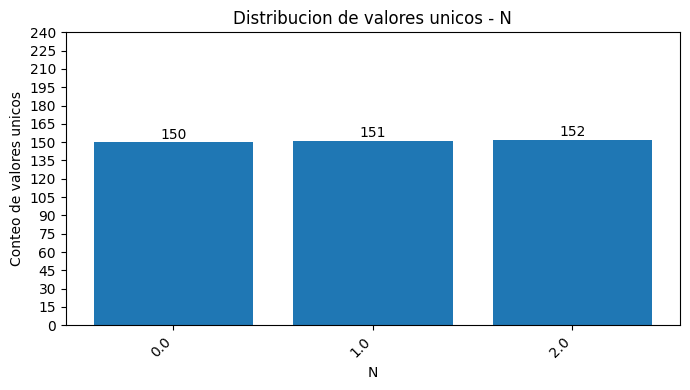

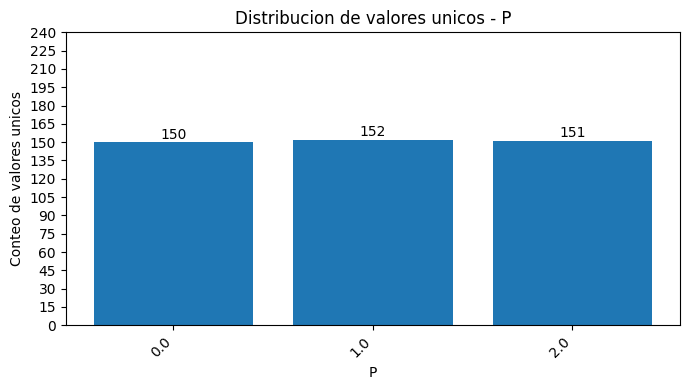

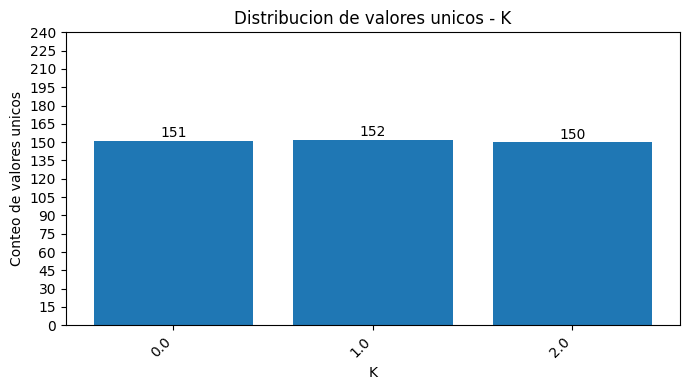

In [15]:
import matplotlib.pyplot as plt

cols = ["N", "P", "K"]

for col in cols:
    counts = test_data[col].value_counts(dropna=False).sort_index()

    plt.figure(figsize=(7, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel(col)
    for i, v in enumerate(counts.values):
        plt.text(i, v + 0.5, str(v), ha='center', va='bottom')
    plt.ylabel("Conteo de valores unicos")
    plt.yticks(range(0, max(counts.values) + 100, max(1, max(counts.values) // 10)))
    plt.title(f"Distribucion de valores unicos - {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Intento extenso

In [16]:
import pandas as pd
import numpy as np
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.experimental import enable_iterative_imputer  # Necesario para IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore", category=ConvergenceWarning)

class ImputadorSinLeakage:
    def __init__(self, min_frac_no_nulos=0.05, max_iter_reimputacion=11):
        self.min_frac_no_nulos = min_frac_no_nulos
        self.max_iter_reimputacion = max_iter_reimputacion
        
        # Artefactos que aprenderemos EXCLUSIVAMENTE del Train
        self.columnas_validas = None
        self.limites_clip = None
        self.modelos_imputacion = {}
        self.columnas_por_grupo = {}
        
    def _extraer_tratamiento(self, df):
        df_out = df.copy()
        if 'Tratamiento' in df_out.columns:
            df_out['Tratamiento_num'] = df_out['Tratamiento'].str.extract(r'T(\d+)').astype(float)
        return df_out

    def fit_transform(self, df_train):
        """Aprende parámetros y modelos del TRAIN, y retorna el TRAIN imputado."""
        print("🏋️ Fase TRAIN: Aprendiendo parámetros y entrenando modelos...")
        df = self._extraer_tratamiento(df_train)
        
        # 1. Aprender columnas válidas (>5% datos)
        df_num = df.select_dtypes(include=[float, int])
        mascara_nulos = df_num.isna().mean() < (1 - self.min_frac_no_nulos)
        self.columnas_validas = df_num.columns[mascara_nulos]
        df_num = df_num[self.columnas_validas]
        
        # 2. Aprender límites de Clipping (1% y 99%)
        self.limites_clip = df_num.quantile([0.01, 0.99]).T
        self.limites_clip.columns = ['min_val', 'max_val']
        
        df_original = df_num.copy()
        df_imputed = df_num.copy()
        
        def entrenar_e_imputar(grupo_data, tratamiento):
            c_validas = grupo_data.columns[~grupo_data.isna().all()]
            self.columnas_por_grupo[tratamiento] = c_validas
            
            grupo_valido = grupo_data[c_validas]
            mascara_orig = ~grupo_valido.isna()
            vals_orig = grupo_valido.copy()
            
            imputer = IterativeImputer(
                estimator=RandomForestRegressor(n_estimators=10, random_state=42), 
                max_iter=20, random_state=42
            )
            
            # FIT_TRANSFORM: Entrena el modelo y lo aplica
            imputado = imputer.fit_transform(grupo_valido)
            self.modelos_imputacion[tratamiento] = imputer # GUARDA EL MODELO
            
            df_res = pd.DataFrame(imputado, columns=c_validas, index=grupo_data.index)
            df_res[mascara_orig] = vals_orig[mascara_orig] # Restaurar originales
            
            out = pd.DataFrame(index=grupo_data.index, columns=grupo_data.columns)
            out[c_validas] = df_res
            return out

        # 3. Imputación inicial Train
        tratamientos = df_num['Tratamiento_num'].dropna().unique()
        for t in tratamientos:
            mask = df_num['Tratamiento_num'] == t
            grupo = df_num.loc[mask].drop(columns=['Tratamiento_num'])
            df_imputed.loc[mask, grupo.columns] = entrenar_e_imputar(grupo, t)

        # 4. Bucle Reimputación Negativos (Entrenando nuevos modelos para la versión final)
        i = 0
        while (df_imputed.drop(columns=['Tratamiento_num'], errors='ignore') < 0).any().any() and i < self.max_iter_reimputacion:
            for col in df_imputed.columns:
                if col != 'Tratamiento_num':
                    mask_neg = df_imputed[col] < 0
                    df_imputed.loc[mask_neg, col] = df_original.loc[mask_neg, col].fillna(np.nan)
            
            for t in tratamientos:
                mask = df_imputed['Tratamiento_num'] == t
                grupo = df_imputed.loc[mask].drop(columns=['Tratamiento_num'])
                if grupo.isna().any().any():
                    df_imputed.loc[mask, grupo.columns] = entrenar_e_imputar(grupo, t)
            i += 1

        # 5. Aplicar Clipping a Train
        self._aplicar_clipping(df_imputed, df_original)
        return df_imputed

    def transform(self, df_test):
        """Aplica los modelos y límites guardados al TEST (sin reentrenar)."""
        df = self._extraer_tratamiento(df_test)
        
        # 1. Forzar exactamente las mismas columnas que el Train
        for c in self.columnas_validas:
            if c not in df.columns:
                df[c] = np.nan
        df_num = df[self.columnas_validas] # Mantener orden estricto
        
        df_original = df_num.copy()
        df_imputed = df_num.copy()
        
        def transformar_solo(grupo_data, tratamiento):
            if tratamiento not in self.modelos_imputacion:
                return grupo_data # Tratamiento nuevo no visto en train
                
            c_validas = self.columnas_por_grupo[tratamiento]
            imputer = self.modelos_imputacion[tratamiento]
            
            grupo_valido = grupo_data.reindex(columns=c_validas)
            mascara_orig = ~grupo_valido.isna()
            vals_orig = grupo_valido.copy()
            
            # TRANSFORM: Usa el modelo guardado, NO usa fit()
            imputado = imputer.transform(grupo_valido)
            
            df_res = pd.DataFrame(imputado, columns=c_validas, index=grupo_data.index)
            df_res[mascara_orig] = vals_orig[mascara_orig]
            
            out = pd.DataFrame(index=grupo_data.index, columns=grupo_data.columns)
            out[c_validas] = df_res
            return out

        # 2. Imputación inicial Test
        tratamientos = df_num['Tratamiento_num'].dropna().unique()
        for t in tratamientos:
            mask = df_num['Tratamiento_num'] == t
            grupo = df_num.loc[mask].drop(columns=['Tratamiento_num'])
            df_imputed.loc[mask, grupo.columns] = transformar_solo(grupo, t)

        # 3. Bucle Reimputación Negativos (Usando transform)
        i = 0
        while (df_imputed.drop(columns=['Tratamiento_num'], errors='ignore') < 0).any().any() and i < self.max_iter_reimputacion:
            for col in df_imputed.columns:
                if col != 'Tratamiento_num':
                    mask_neg = df_imputed[col] < 0
                    df_imputed.loc[mask_neg, col] = df_original.loc[mask_neg, col].fillna(np.nan)
            
            for t in tratamientos:
                mask = df_imputed['Tratamiento_num'] == t
                grupo = df_imputed.loc[mask].drop(columns=['Tratamiento_num'])
                if grupo.isna().any().any():
                    df_imputed.loc[mask, grupo.columns] = transformar_solo(grupo, t)
            i += 1
            
        # 4. Aplicar Clipping a Test (usando los límites del Train)
        self._aplicar_clipping(df_imputed, df_original)
        return df_imputed

    def _aplicar_clipping(self, df_imputed, df_original):
        """Función auxiliar para aplicar clipping solo a valores originalmente nulos."""
        for col in df_imputed.columns:
            if col in self.limites_clip.index and col != 'Tratamiento_num':
                min_v = self.limites_clip.loc[col, 'min_val']
                max_v = self.limites_clip.loc[col, 'max_val']
                mask_imp = df_original[col].isna()
                df_imputed.loc[mask_imp, col] = df_imputed.loc[mask_imp, col].clip(lower=min_v, upper=max_v)

In [17]:
# 1. Inicializas tu imputador
imputador = ImputadorSinLeakage()

# 2. Entrenas e imputas el dataset de Train
df_train_imputado = imputador.fit_transform(train_data)

# 3. Aplicas al dataset de Test (solo usa transform, sin fugas de datos)
df_test_imputado = imputador.transform(test_data)

🏋️ Fase TRAIN: Aprendiendo parámetros y entrenando modelos...


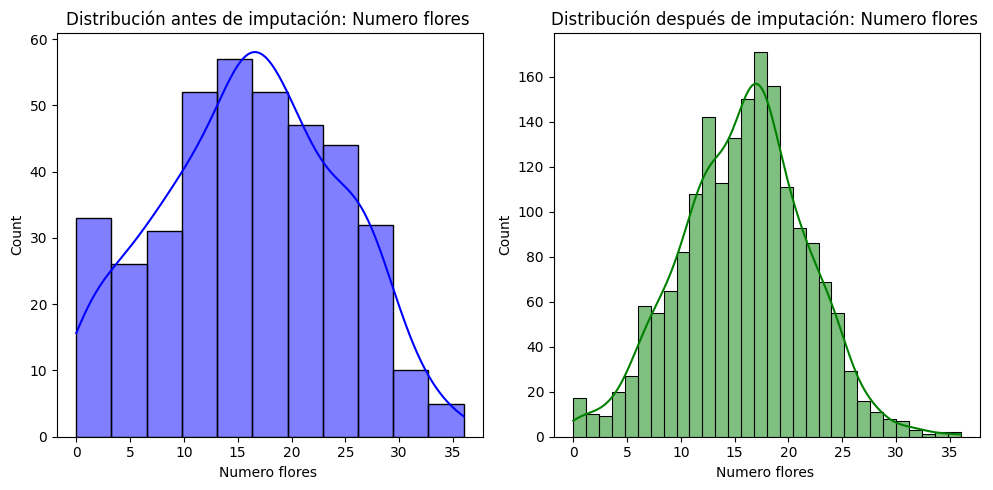

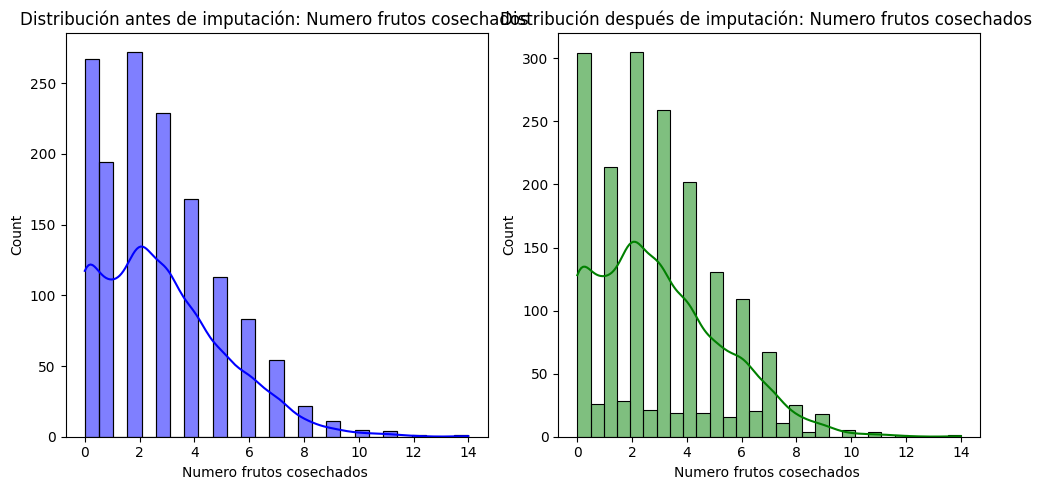

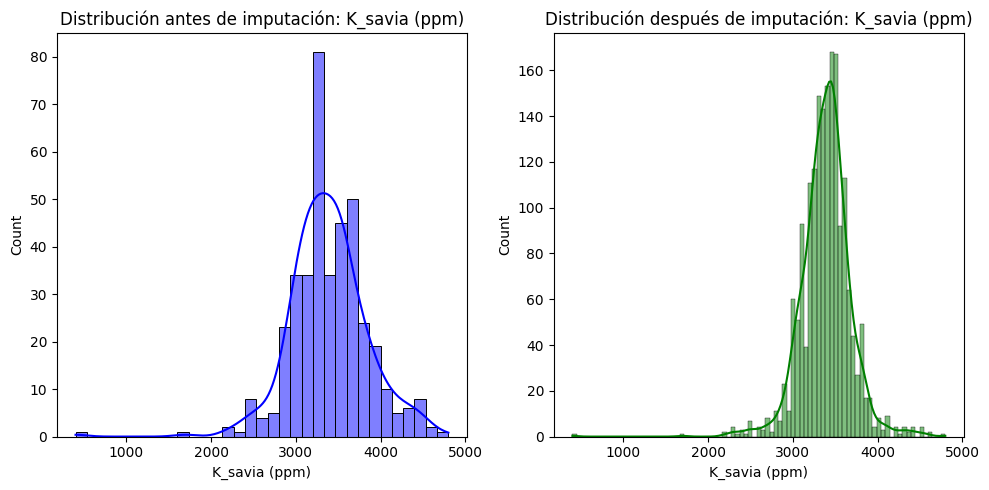

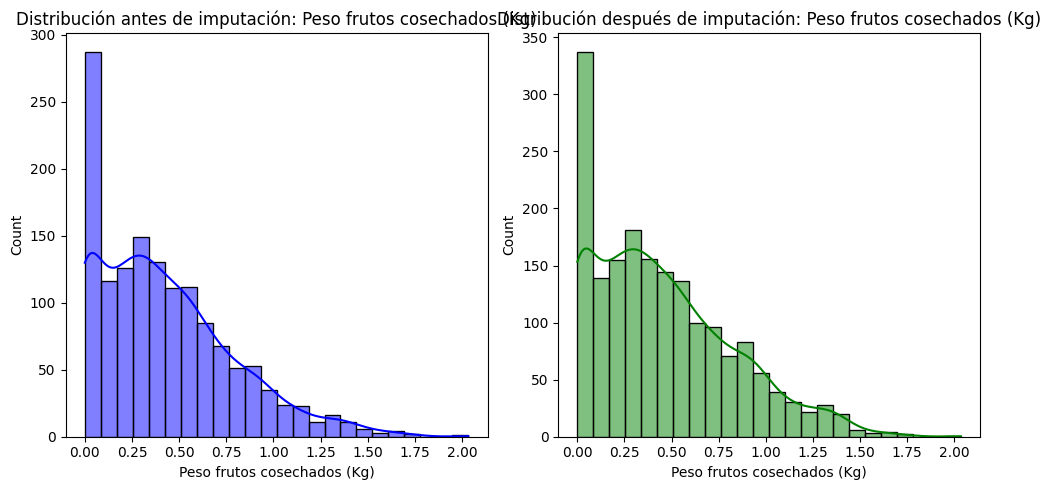

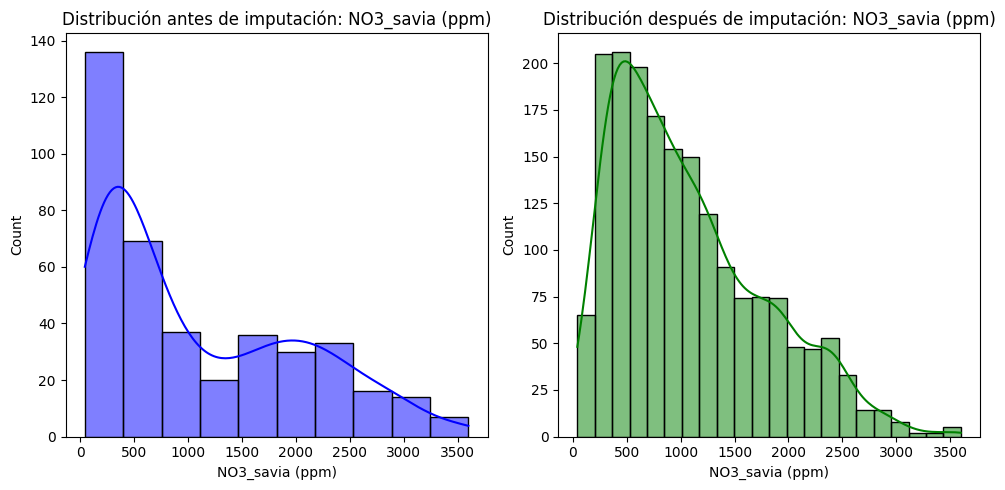

In [18]:
import seaborn as sns
variables = ['Numero flores ', 'Numero frutos cosechados ','K_savia (ppm)', 'Peso frutos cosechados (Kg)', 'NO3_savia (ppm)']

# Crear gráficos comparando antes y después de la imputación
for variable in variables:
    plt.figure(figsize=(10, 5))

    # Histograma antes de la imputación
    plt.subplot(1, 2, 1)
    sns.histplot(train_data[variable], kde=True, color='blue')
    plt.title(f'Distribución antes de imputación: {variable}')
    
    # Histograma después de la imputación
    plt.subplot(1, 2, 2)
    sns.histplot(df_train_imputado[variable], kde=True, color='green')
    plt.title(f'Distribución después de imputación: {variable}')
    
    plt.tight_layout()
    plt.show()

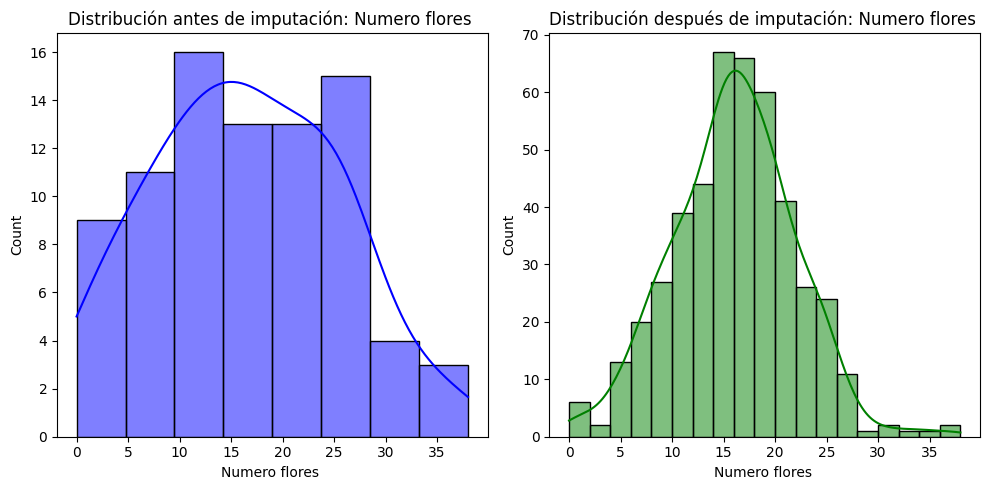

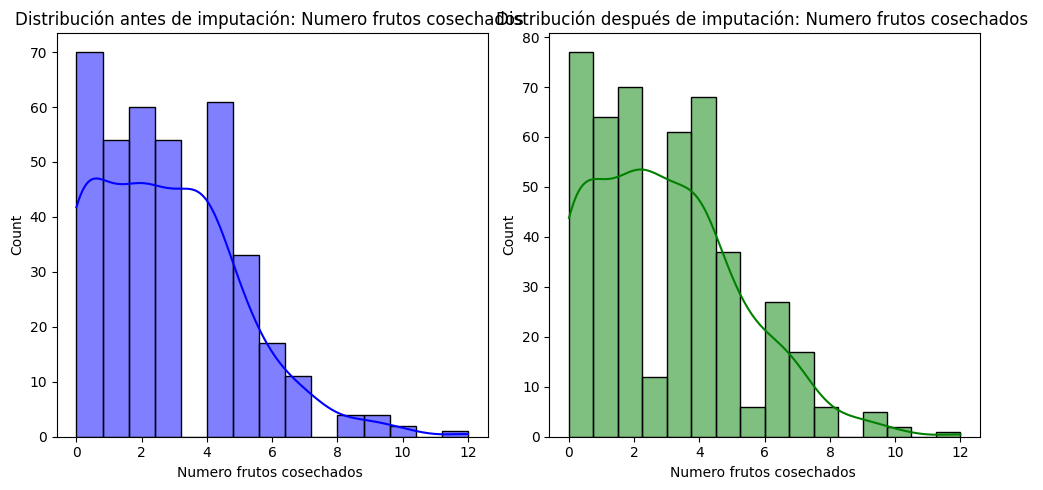

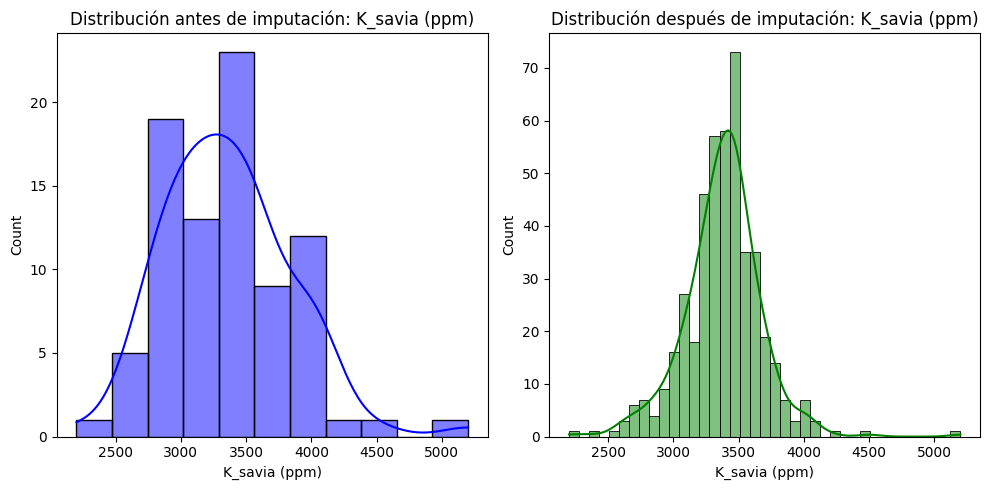

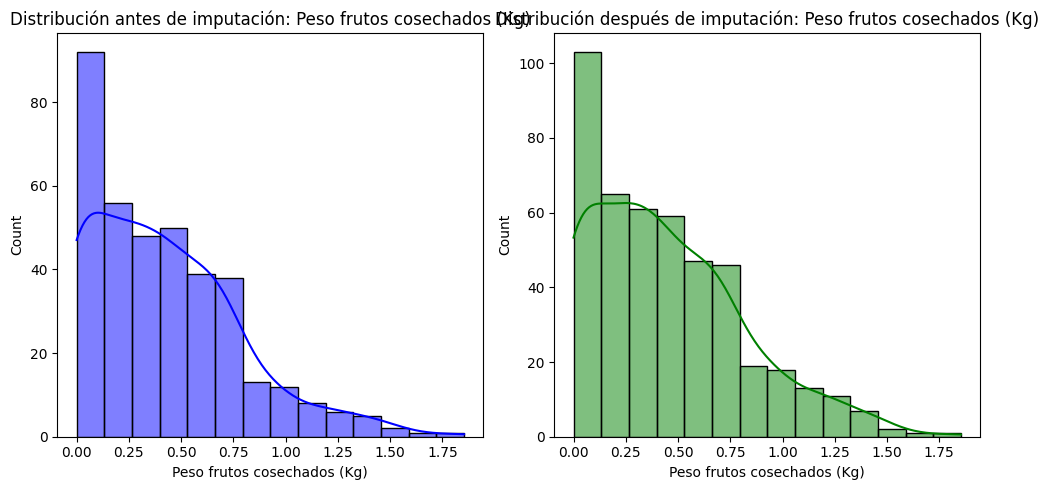

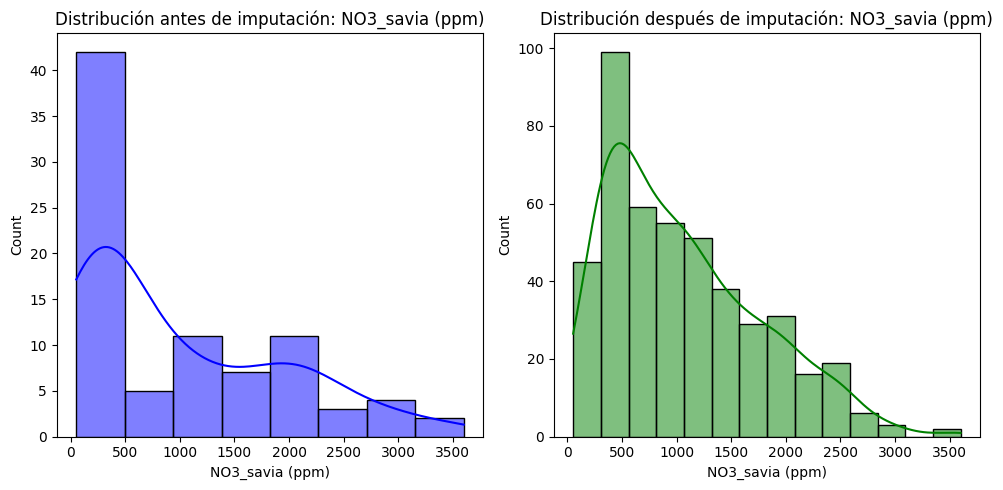

In [19]:
import seaborn as sns
variables = ['Numero flores ', 'Numero frutos cosechados ','K_savia (ppm)', 'Peso frutos cosechados (Kg)', 'NO3_savia (ppm)']

# Crear gráficos comparando antes y después de la imputación
for variable in variables:
    plt.figure(figsize=(10, 5))

    # Histograma antes de la imputación
    plt.subplot(1, 2, 1)
    sns.histplot(test_data[variable], kde=True, color='blue')
    plt.title(f'Distribución antes de imputación: {variable}')
    
    # Histograma después de la imputación
    plt.subplot(1, 2, 2)
    sns.histplot(df_test_imputado[variable], kde=True, color='green')
    plt.title(f'Distribución después de imputación: {variable}')
    
    plt.tight_layout()
    plt.show()

In [20]:
test_data['Numero frutos cosechados ']

1347    8.0
1962    3.0
2236    3.0
1253    4.0
1982    2.0
       ... 
751     2.0
759     4.0
391     NaN
1299    4.0
1465    4.0
Name: Numero frutos cosechados , Length: 453, dtype: float64

In [27]:
display(df_test_imputado['Numero frutos cosechados '].head(20))

1347    8.0
1962    3.0
2236    3.0
1253    4.0
1982    2.0
592     0.0
1766    2.0
1869    2.0
739     5.0
2247    5.0
860     1.0
831     7.0
385     0.9
286     0.2
1015    2.0
852     2.0
1326    7.0
309     3.4
456     1.3
337     0.8
Name: Numero frutos cosechados , dtype: float64

## Simple Version

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

def impute_data(train_data, test_data):

    # Por defecto, si no se pasa nada, es una lista vacía
    if columnas_productividad is None:
        columnas_productividad = []

        
    train = train_data.copy()
    test = test_data.copy()

    # --- NOTE: NUEVA REGLA: Llenar con 0 los nulos de productividad SOLO EN TEST ---
    for col in columnas_productividad:
        if col in test.columns:
            test[col] = test[col].fillna(0)

    # 1. Extraer tratamiento
    train['Tratamiento_num'] = train['Tratamiento'].str.extract(r'T(\d+)').astype(float)
    test['Tratamiento_num'] = test['Tratamiento'].str.extract(r'T(\d+)').astype(float)

    # 2. Seleccionar columnas SOLO basados en el Train
    min_frac_no_nulos = 0.05
    df_train_num = train.select_dtypes(include=[float, int])
    
    # Calcular columnas válidas en train
    columnas_validas = df_train_num.columns[df_train_num.isna().mean() < (1 - min_frac_no_nulos)]
    df_train_num = df_train_num[columnas_validas]
    
    # Forzar al test a tener EXACTAMENTE las mismas columnas (rellenando con NaN si falta alguna)
    df_test_num = pd.DataFrame(index=test.index)
    for col in columnas_validas:
        df_test_num[col] = test[col] if col in test.columns else np.nan

    # 3. Límites de clipping (Solo Train)
    limites_clip = df_train_num.quantile([0.01, 0.99]).T
    limites_clip.columns = ['min_val', 'max_val']

    df_train_original = df_train_num.copy()
    df_test_original = df_test_num.copy()

    df_train_imputed = df_train_num.copy()
    df_test_imputed = df_test_num.copy()

    # 4. Iterar por tratamientos conocidos en el Train
    for tratamiento in df_train_num['Tratamiento_num'].dropna().unique():
        mask_train = df_train_num['Tratamiento_num'] == tratamiento
        mask_test = df_test_num['Tratamiento_num'] == tratamiento

        grupo_train = df_train_num.loc[mask_train].drop(columns=['Tratamiento_num'])
        grupo_test = df_test_num.loc[mask_test].drop(columns=['Tratamiento_num'])

        # Solo imputar si hay columnas numéricas válidas para este grupo
        cols_imputar = grupo_train.columns[~grupo_train.isna().all()]
        if len(cols_imputar) == 0:
            continue
            
        # Instanciar modelo con min_value=0 para evitar negativos automáticamentee
        imputer = IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=10, random_state=42),
            max_iter=20, random_state=42, min_value=0
        )

        # FIT_TRANSFORM en Train
        imputado_train = imputer.fit_transform(grupo_train[cols_imputar])
        df_train_imputed.loc[mask_train, cols_imputar] = imputado_train
        
        # Restaurar originales no nulos en Train
        mascara_orig_train = ~grupo_train[cols_imputar].isna()
        df_train_imputed.loc[mask_train, cols_imputar] = df_train_imputed.loc[mask_train, cols_imputar].where(~mascara_orig_train, grupo_train[cols_imputar])

        # TRANSFORM en Test (si hay datos para este tratamiento)
        if mask_test.any():
            imputado_test = imputer.transform(grupo_test[cols_imputar])
            df_test_imputed.loc[mask_test, cols_imputar] = imputado_test
            
            # Restaurar originales no nulos en Test
            mascara_orig_test = ~grupo_test[cols_imputar].isna()
            df_test_imputed.loc[mask_test, cols_imputar] = df_test_imputed.loc[mask_test, cols_imputar].where(~mascara_orig_test, grupo_test[cols_imputar])

    # 5. Aplicar Clipping SOLO a los valores que eran NaN originalmente
    for col in df_train_imputed.columns:
        if col in limites_clip.index and col != 'Tratamiento_num':
            min_v, max_v = limites_clip.loc[col, 'min_val'], limites_clip.loc[col, 'max_val']
            
            # Clip en Train
            mask_imp_train = df_train_original[col].isna()
            df_train_imputed.loc[mask_imp_train, col] = df_train_imputed.loc[mask_imp_train, col].clip(lower=min_v, upper=max_v)
            
            # Clip en Test
            mask_imp_test = df_test_original[col].isna()
            df_test_imputed.loc[mask_imp_test, col] = df_test_imputed.loc[mask_imp_test, col].clip(lower=min_v, upper=max_v)

    return df_train_imputed, df_test_imputed

In [30]:
df_train_imputed_V2, df_test_imputed_V2 = impute_data(train_data, test_data)

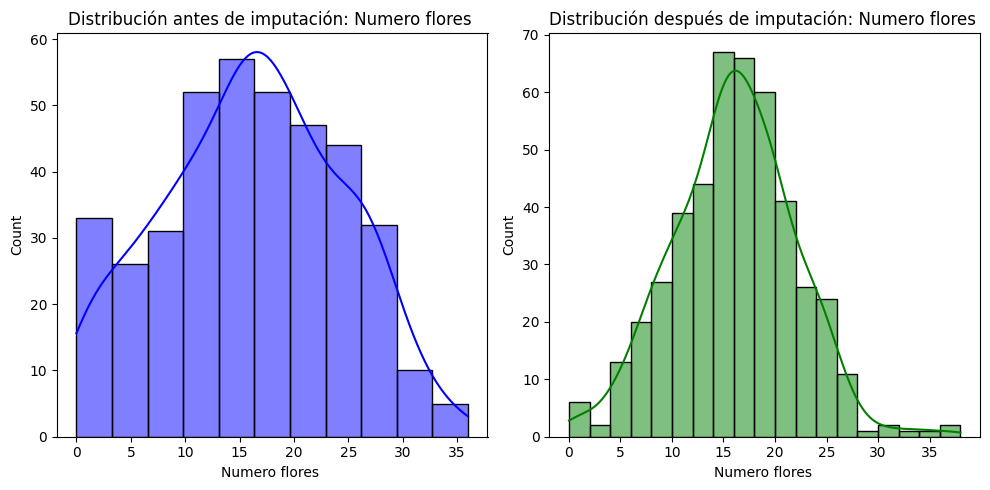

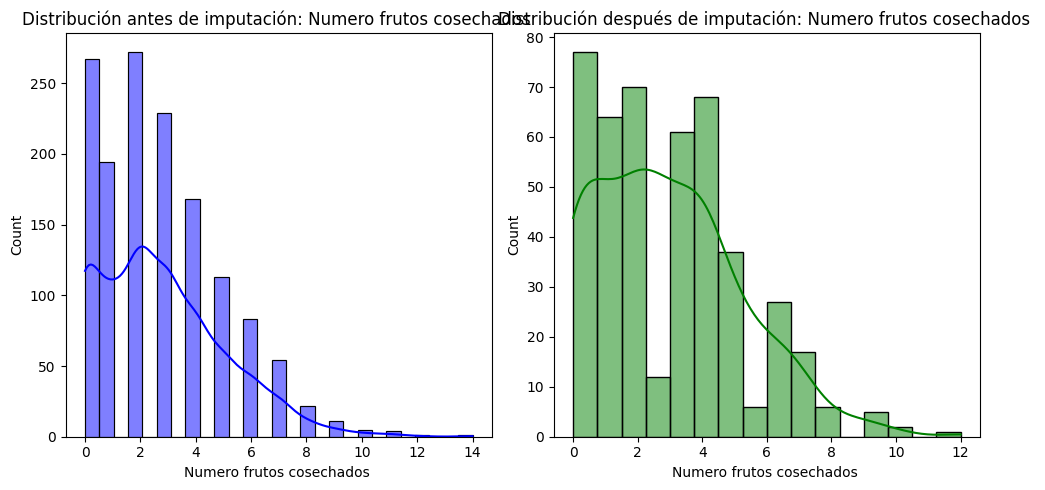

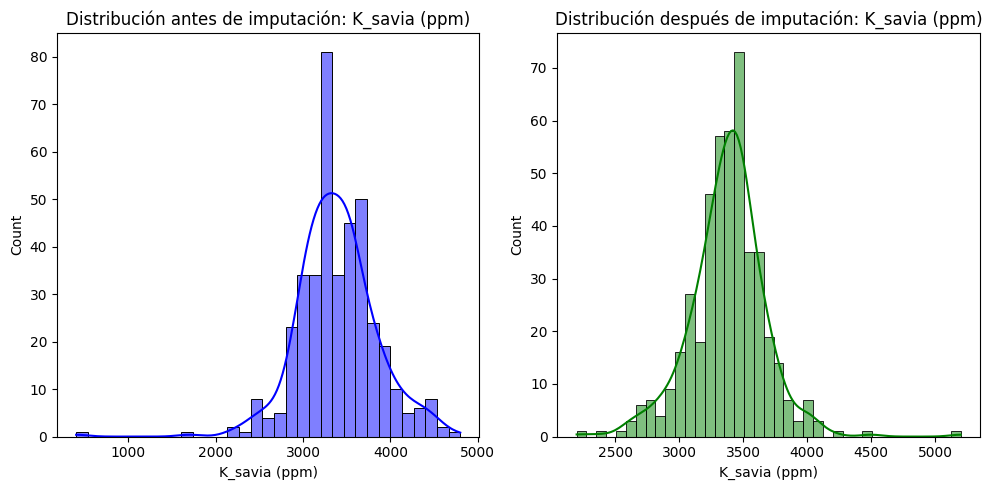

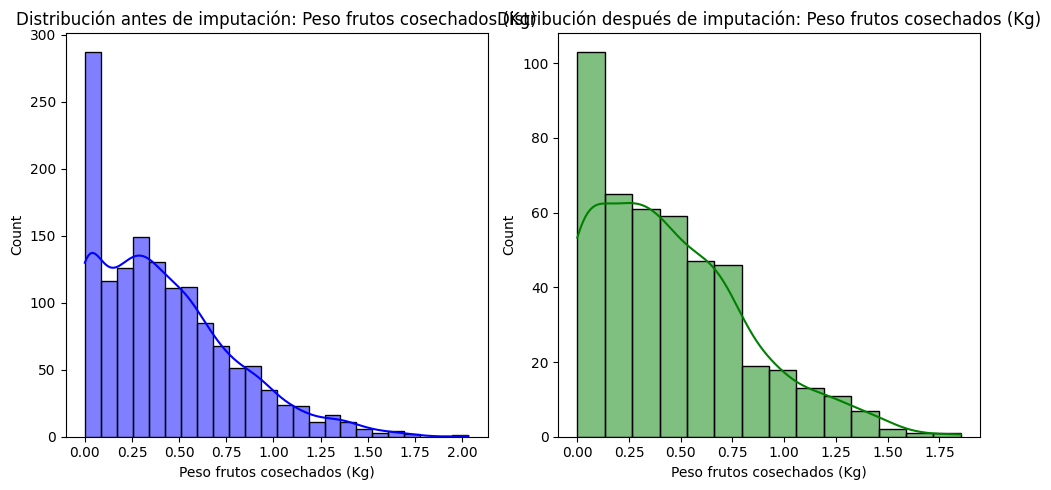

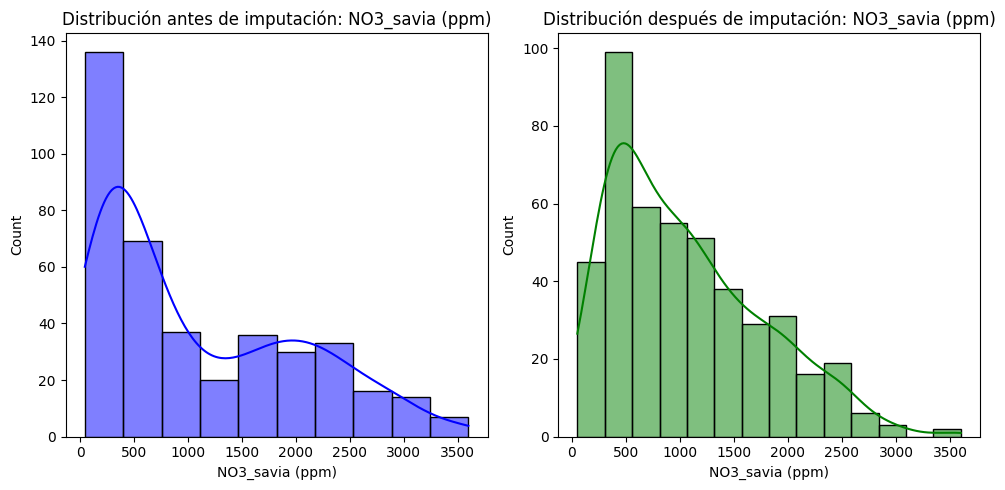

In [34]:
import seaborn as sns
variables = ['Numero flores ', 'Numero frutos cosechados ','K_savia (ppm)', 'Peso frutos cosechados (Kg)', 'NO3_savia (ppm)']

# Crear gráficos comparando antes y después de la imputación
for variable in variables:
    plt.figure(figsize=(10, 5))

    # Histograma antes de la imputación
    plt.subplot(1, 2, 1)
    sns.histplot(train_data[variable], kde=True, color='blue')
    plt.title(f'Distribución antes de imputación: {variable}')
    
    # Histograma después de la imputación
    plt.subplot(1, 2, 2)
    sns.histplot(df_test_imputed_V2[variable], kde=True, color='green')
    plt.title(f'Distribución después de imputación: {variable}')
    
    plt.tight_layout()
    plt.show()

In [36]:
display(df_test_imputed_V2['Numero frutos cosechados '].head(20))

1347    8.0
1962    3.0
2236    3.0
1253    4.0
1982    2.0
592     0.0
1766    2.0
1869    2.0
739     5.0
2247    5.0
860     1.0
831     7.0
385     0.9
286     0.2
1015    2.0
852     2.0
1326    7.0
309     3.4
456     1.3
337     0.8
Name: Numero frutos cosechados , dtype: float64

In [38]:
df_train_imputed_V2.columns

Index(['Altura planta (cm)', 'Clorofila (SPAD)', 'Numero flores ',
       'Numero frutos cosechados ', 'Peso frutos cosechados (Kg)',
       'Tamanno altura (mm)', 'pH_savia', 'K_savia (ppm)', 'Ca_savia (ppm)',
       'Na_savia (ppm)', 'NO3_savia (ppm)', 'Conductividad_savia (mS/cm)',
       'pH_suelo_Horiba', 'K_suelo_Horiba (ppm)', 'Ca_suelo_Horiba (ppm)',
       'Na_suelo_Horiba (ppm)', 'NO3_suelo_Horiba (ppm)',
       'Conductividad_suelo_Horiba (mS/cm)', 'Tamanno cintura (mm)',
       '7in1_Ph[pH]', '7in1_Moisture[%RH]', '7in1_S_Temperature[C]',
       'Air_sensor_Temperature[C]', 'Air_sensor_Humidity[%RH]',
       '7in1_Conductivity[mS/cm]', 'Pynamometer_Radiation[W/m2]', 'N', 'P',
       'K', 'Año', 'Mes', 'Día', 'Tratamiento_num'],
      dtype='object')